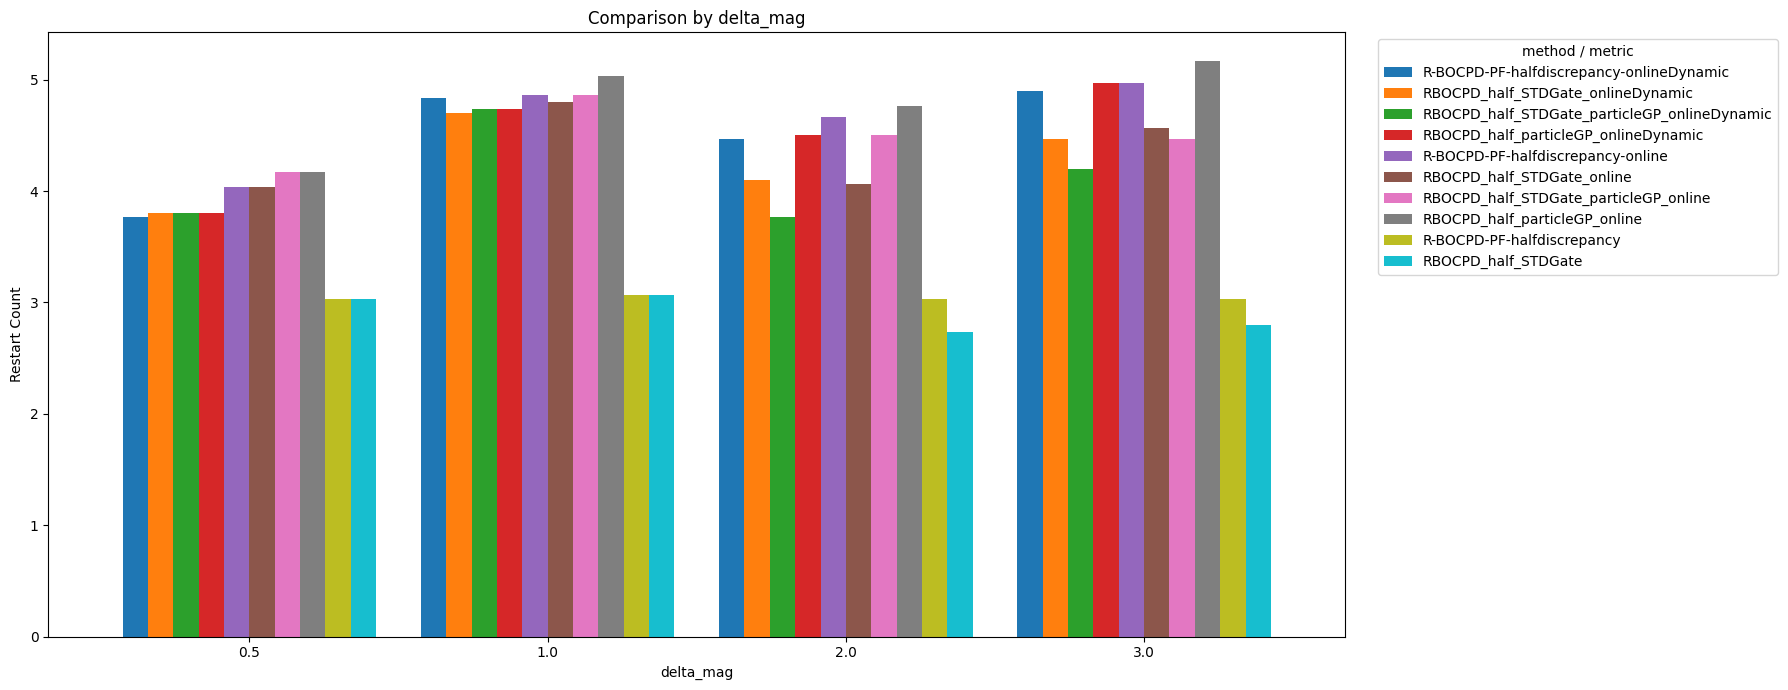

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 读入两个 csv
df1 = pd.read_csv("C:\\Users\\yxu59\\files\\autumn2025\\park\\DynamicCalibration\\figs\\sudden_ablation_supple_v7newonline\\restart_mode_stats.csv")
df2 = pd.read_csv("C:\\Users\\yxu59\\files\\autumn2025\\park\\DynamicCalibration\\figs\\sudden_ablation_supple_v7online\\ablation_sudden_restart_stats.csv")
df3 = pd.read_csv("C:\\Users\\yxu59\\files\\autumn2025\\park\\DynamicCalibration\\figs\\sudden_ablation\\ablation_sudden_restart_stats.csv")

# -----------------------------
# 第一份：计算 n_steps - n_none
# -----------------------------
df1["value"] = df1["n_full"]

avg1 = (
    df1.groupby(["method", "delta_mag"], as_index=False)["value"]
       .mean()
)
avg1["series"] = avg1["method"]

# -----------------------------
# 第二份：取 full_restart_count
# -----------------------------
avg2 = (
    df2.groupby(["method", "delta_mag"], as_index=False)["full_restart_count"]
       .mean()
       .rename(columns={"full_restart_count": "value"})
)
avg2["series"] = avg2["method"] 

avg3 = (
    df3.groupby(["method", "delta_mag"], as_index=False)["full_restart_count"]
       .mean()
       .rename(columns={"full_restart_count": "value"})
)
avg3["series"] = avg3["method"] 

# -----------------------------
# 合并两部分数据
# -----------------------------
plot_df = pd.concat(
    [
        avg1[["delta_mag", "series", "value"]],
        avg2[["delta_mag", "series", "value"]],
        avg3[["delta_mag", "series", "value"]],
    ],
    ignore_index=True
)

# 透视表：行是 delta_mag，列是不同 series，值是平均值
pivot_df = plot_df.pivot(index="delta_mag", columns="series", values="value")

# 按 delta_mag 排序
pivot_df = pivot_df.sort_index()

# 按你希望的顺序排列图例/柱子
series_order = (
    avg1["series"].drop_duplicates().tolist() +
    [s for s in avg2["series"].drop_duplicates().tolist() if s not in avg1["series"].tolist()] +
    [s for s in avg3["series"].drop_duplicates().tolist() if "dual" not in s and "hybrid" not in s]
)
pivot_df = pivot_df.reindex(columns=series_order)

# -----------------------------
# 画 grouped bar chart
# -----------------------------
ax = pivot_df.plot(
    kind="bar",
    figsize=(18, 7),
    width=0.85
)

ax.set_xlabel("delta_mag")
ax.set_ylabel("Restart Count")
ax.set_title("Comparison by delta_mag")
ax.legend(title="method / metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 如果你还想看具体数值表
# print(plot_df.sort_values(["delta_mag", "series"]))

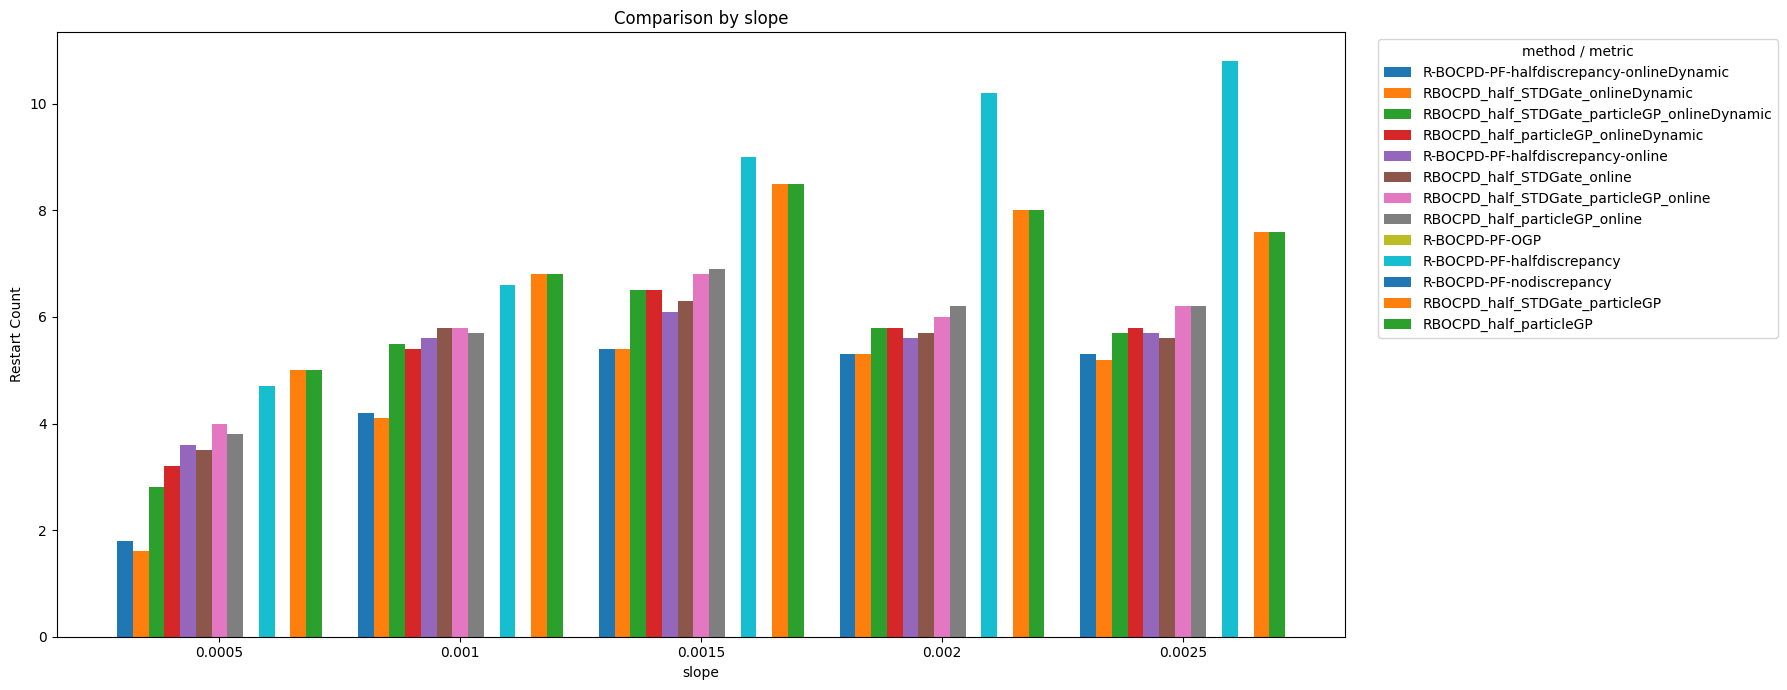

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 读入两个 csv
df1 = pd.read_csv("C:\\Users\\yxu59\\files\\autumn2025\\park\\DynamicCalibration\\figs\\slope_deltaCmp_v8newonline\\restart_mode_stats.csv")
df2 = pd.read_csv("C:\\Users\\yxu59\\files\\autumn2025\\park\\DynamicCalibration\\figs\\slope_deltaCmp_v8online\\restart_mode_stats.csv")
df3 = pd.read_csv("C:\\Users\\yxu59\\files\\autumn2025\\park\\DynamicCalibration\\figs\\slope_ablation\\restart_mode_stats.csv")

# -----------------------------
# 第一份：计算 n_steps - n_none
# -----------------------------
df1["value"] = df1["n_full"]

avg1 = (
    df1.groupby(["method", "slope"], as_index=False)["value"]
       .mean()
)
avg1["series"] = avg1["method"]

# -----------------------------
# 第二份：取 full_restart_count
# -----------------------------
avg2 = (
    df2.groupby(["method", "slope"], as_index=False)["n_full"]
       .mean()
       .rename(columns={"n_full": "value"})
)
avg2["series"] = avg2["method"] 

avg3 = (
    df3.groupby(["method", "slope"], as_index=False)["n_full"]
       .mean()
       .rename(columns={"n_full": "value"})
)
avg3["series"] = avg3["method"] 

# -----------------------------
# 合并两部分数据
# -----------------------------
plot_df = pd.concat(
    [
        avg1[["slope", "series", "value"]],
        avg2[["slope", "series", "value"]],
        avg3[["slope", "series", "value"]],
    ],
    ignore_index=True
)

# 透视表：行是 delta_mag，列是不同 series，值是平均值
pivot_df = plot_df.pivot(index="slope", columns="series", values="value")

# 按 delta_mag 排序
pivot_df = pivot_df.sort_index()

# 按你希望的顺序排列图例/柱子
series_order = (
    avg1["series"].drop_duplicates().tolist() +
    [s for s in avg2["series"].drop_duplicates().tolist() if s not in avg1["series"].tolist()] +
    [s for s in avg3["series"].drop_duplicates().tolist() if "dual" not in s and "hybrid" not in s]
)
pivot_df = pivot_df.reindex(columns=series_order)

# -----------------------------
# 画 grouped bar chart
# -----------------------------
ax = pivot_df.plot(
    kind="bar",
    figsize=(18, 7),
    width=0.85
)

ax.set_xlabel("slope")
ax.set_ylabel("Restart Count")
ax.set_title("Comparison by slope")
ax.legend(title="method / metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 如果你还想看具体数值表
# print(plot_df.sort_values(["delta_mag", "series"]))

In [ ]:
python -m calib.run_synthetic_mechanism_figures --scenarios sudden --method-set basis_ablation --seeds 0 1 2 3 4 --plot-all-seeds --out_dir figs\mechanism_figures_basis20_fixedhyper_ablation_20260410_mag1 --sudden-mag 1.0 --sudden-seg-len 200

In [13]:
!pip install openai

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datumaro 1.12.0 requires numpy<2.2.0,>=1.23.4, but you have numpy 2.4.2 which is incompatible.



  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ------------------ --------------------- 0.5/1.2 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 1.0/1.2 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 2.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 2.8 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.1 MB 2.8 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.7 MB/s eta 0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions

In [15]:
import os
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY", "change-me-app-api"),
    base_url="https://uu36451-b94b-dfbd510b.westc.seetacloud.com:8443",
)

resp = client.chat.completions.create(
    model="deepseek-qwen7b-base",
    messages=[
        {"role": "user", "content": "用一句话解释什么是合成生物学。"}
    ],
    temperature=0.7,
    top_p=0.8,
    max_tokens=64,
    extra_headers={
        "X-User-ID": "public-api-test",
    },
)

print(resp.choices[0].message.content)

嗯，合成生物学，这个词听起来有点复杂，但其实应该和生物有关。我先想，生物是生命科学，合成生物学可能和合成有关，可能是设计或制造生命系统。比如，可能不是研究生命，而是设计生命，创造新的生物或者生物产品。比如，可能用于医疗，
